## Anomaly Detection - Credit Card Fraud Analysis

* Introduction
   - Anomaly detection identifies unusual patterns that do not follows the expected behaviour, called outliers. In this notebook, we use anomaly detection to credit card fraud using simple statistics and machine learning (Isolation Forest, LOF) approaches.

* Problem statement
   - Using the same Kaggle dataset on Credit Card Fraud Detection, model past credit card transactions to identify anomalies that correspond to fraudulent transaction. Aim for higher fraudulent transactions while minimising false positive.

* Dataset
   - Data available at [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

### Import libraries

In [1]:
# For EDA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# Anomaly detection models
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Evaluation metrics
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42

### Data loading

In [2]:
# Load data from tmp folder - dataset has been downloaded here from CC Fraud Detection project
df = pd.read_csv("/tmp/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Inspect data structure
df.shape
#df.info

(284807, 31)

In [4]:
#df.describe()

In [5]:
# Check missing values
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Check 'Class' distribution (0 = Valid, 1 = fraud)

Valid transactions: 284315
Fraudulent transactions: 492
Fraud percentage: 0.173%


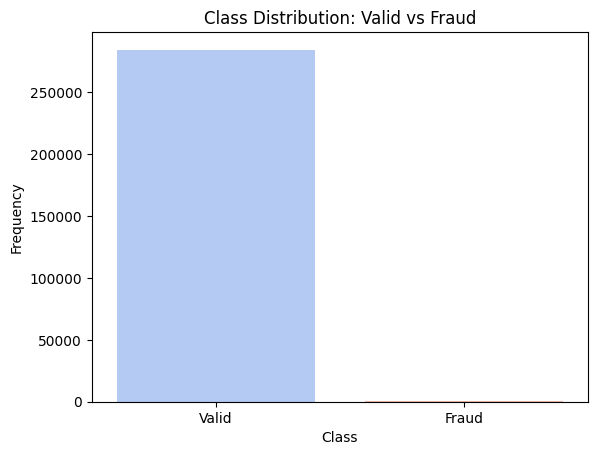

In [6]:
# Check class distribution to determine fraud and valid transactions in the dataset
# Get the count of each class
fraud_count = df["Class"].value_counts()
print(f"Valid transactions: {fraud_count[0]}")
print(f"Fraudulent transactions: {fraud_count[1]}")
print(f"Fraud percentage: {fraud_count[1] / df.shape[0] * 100:.3f}%")


sns.countplot(x="Class", data=df, palette="coolwarm")
plt.title("Class Distribution: Valid vs Fraud")
plt.xticks([0, 1], ["Valid", "Fraud"])
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()



### Check transaction amount distribution

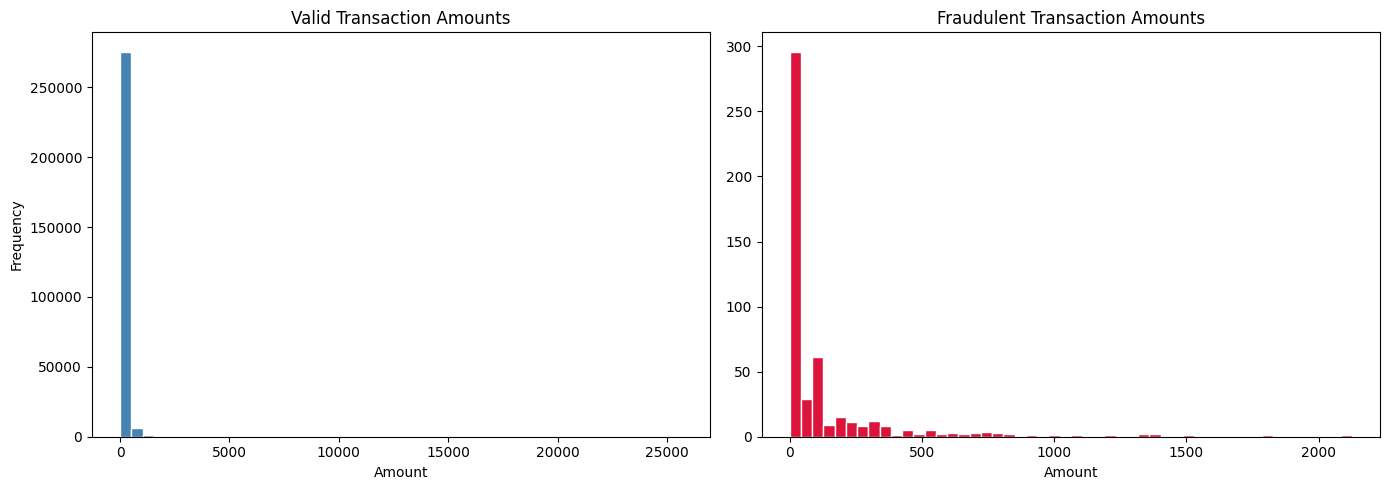

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Class'] == 0]['Amount'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Valid Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

axes[1].hist(df[df['Class'] == 1]['Amount'], bins=50, color='crimson', edgecolor='white')
axes[1].set_title('Fraudulent Transaction Amounts')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.show()

### Check transaction time distribution

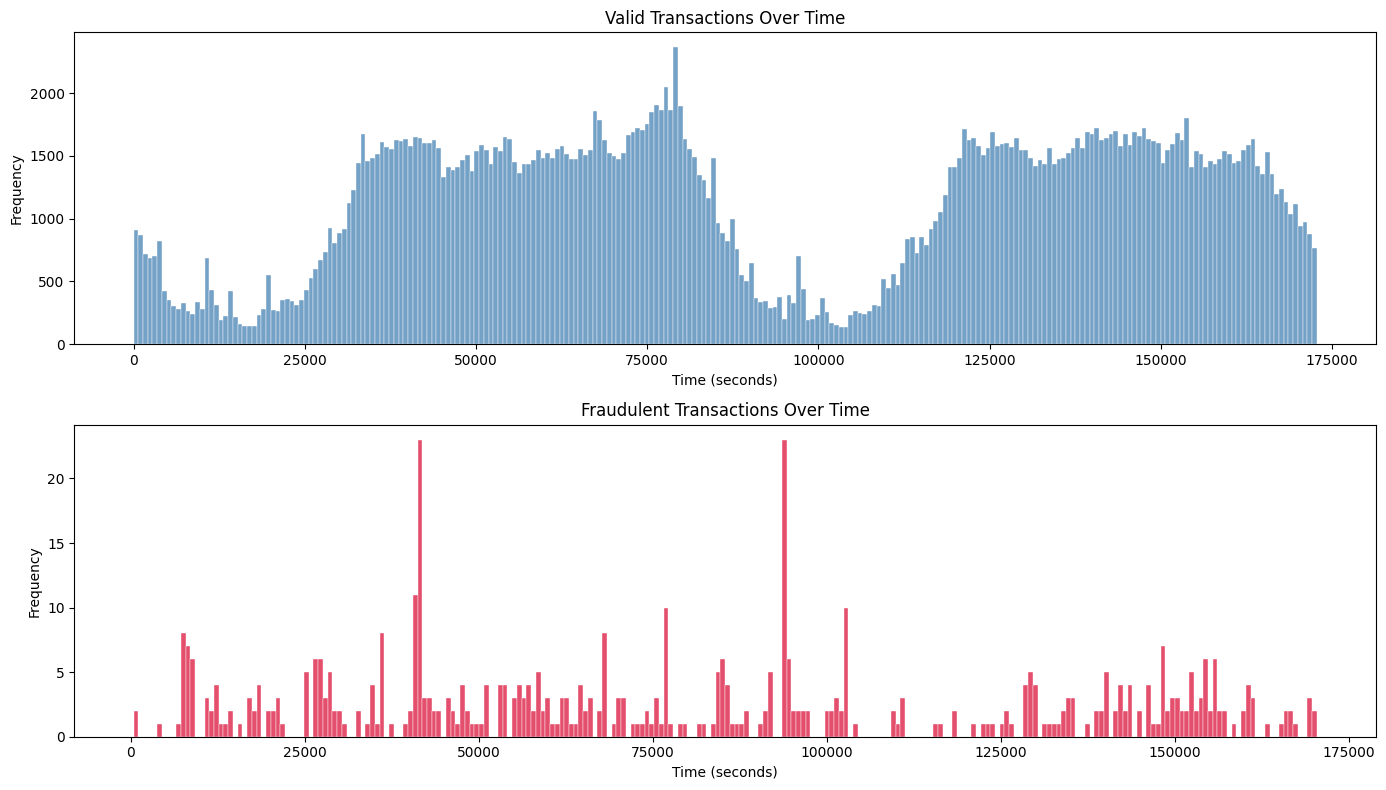

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

sns.histplot(data = df[df['Class'] == 0], x = 'Time', bins = 250, color = 'steelblue', edgecolor = 'white', ax = axes[0])
axes[0].set_title('Valid Transactions Over Time')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Frequency')

sns.histplot(data = df[df['Class'] == 1], x = 'Time', bins = 250, color = 'crimson', edgecolor = 'white', ax = axes[1] )
axes[1].set_title('Fraudulent Transactions Over Time')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

*Observation*
- Valid transactions show a clear cyclical pattern with two distinct peaks (~75,000s and ~150,000s) and two quieter periods across the dataset, suggesting activity follows a regular pattern over time.

- Fraudulent transactions show no distinguishing pattern, they are sparse and noisy across all time windows with occassional spikes but no particular trend.

- This suggests 'Time' has low discriminatory power for fraud detection and can be dropped during preprocessing.


### Check transaction patterns by amount over time

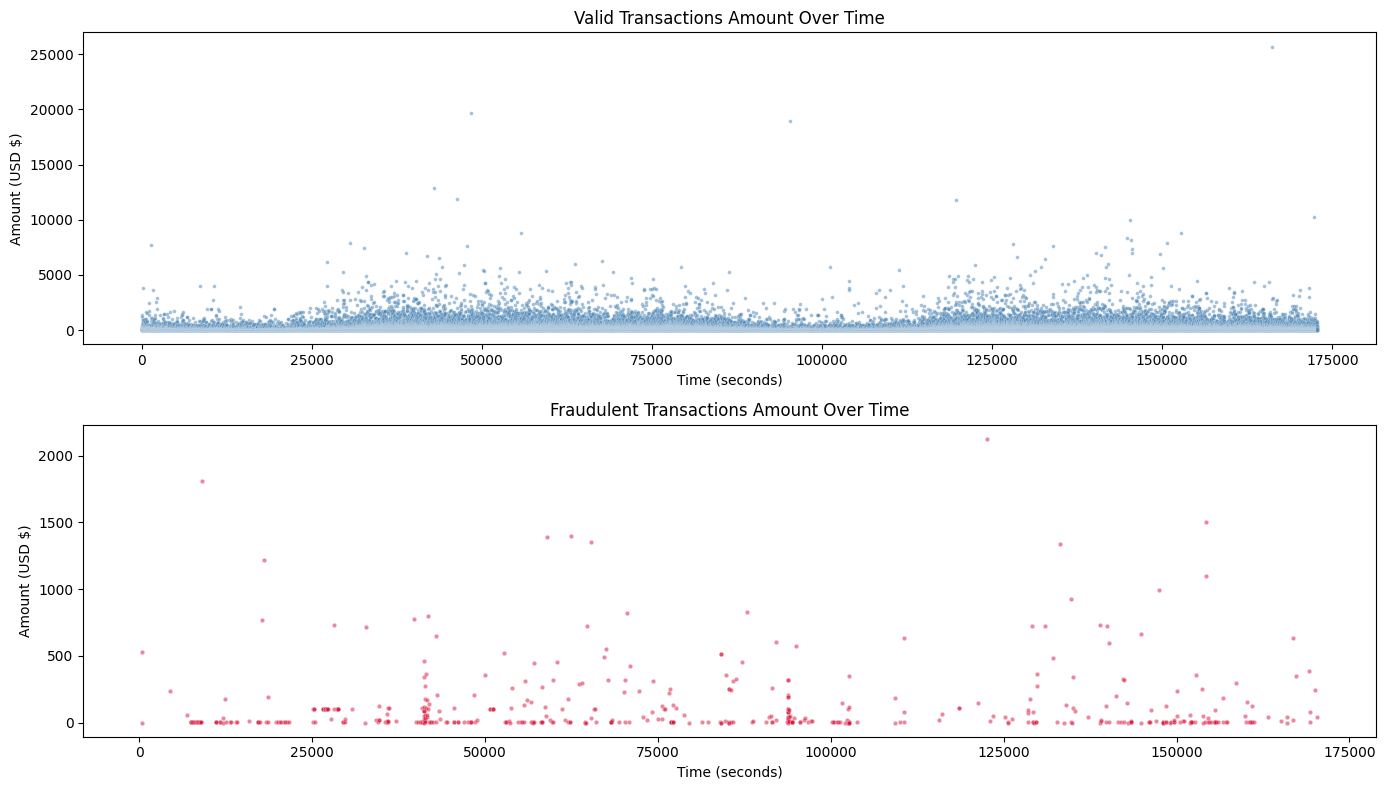

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

sns.scatterplot(data = df[df['Class'] == 0], x = 'Time', y = 'Amount', color = 'steelblue', alpha = 0.5, s = 7, ax = axes[0])
axes[0].set_title('Valid Transactions Amount Over Time')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amount (USD $)')

sns.scatterplot(data = df[df['Class'] == 1], x = 'Time', y = 'Amount', color = 'crimson', alpha = 0.5, s = 10, ax = axes[1])
axes[1].set_title('Fraudulent Transactions Amount Over Time')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Amount (USD $)')

plt.tight_layout()
plt.show()

*Observations*
- As expected, the scatterplot mirrored the histograms above, valid transactions clustered densely at low amounts across all time windows with a few outliers  exceeding USD 20K $.
- Fraudulent transactions are sparse across all time windows with no discernible temporal pattern. Fraud transaction amounts are noticebaly lower than valid transactions, with max just above USD 2K $.
- Interestingly, the outliers in high-value valid transactions can be flagged as fraud using amount-based thresholding alone. This suggest limitation in simple statistics methods.
- This highlights why ML-based anomaly detection across all dataset features is necessary to establish correlations, and distinguish fraud from valid high-value transactions. 

### Summary statistics

In [10]:
print("Summary statistics by Class:")
df.groupby("Class")["Amount"].describe().round(2)

Summary statistics by Class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.29,250.11,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.21,256.68,0.0,1.00,9.25,105.89,2125.87


*Observation*
- Valid transactions have a mean amount of USD 88.29, while fraudulent transactions have a higher mean of USD 122.21.
- Despite the higher mean, fraud transaction amounts have a lower maximum (USD 2,125.87) compared to valid transactions (USD 25,691.16), suggesting fraudsters avoid very large transactions.
- Standard deviation is comparable between classes (valid: USD 250.11, fraud: USD 256.68), suggesting similar spread in transaction amounts overall. However, relative to their respective means, fraud transactions show greater variability — a std of USD 256.68 against a mean of USD 122.21 versus USD 250.11 against USD 88.29 for valid transactions.

### Features correlation

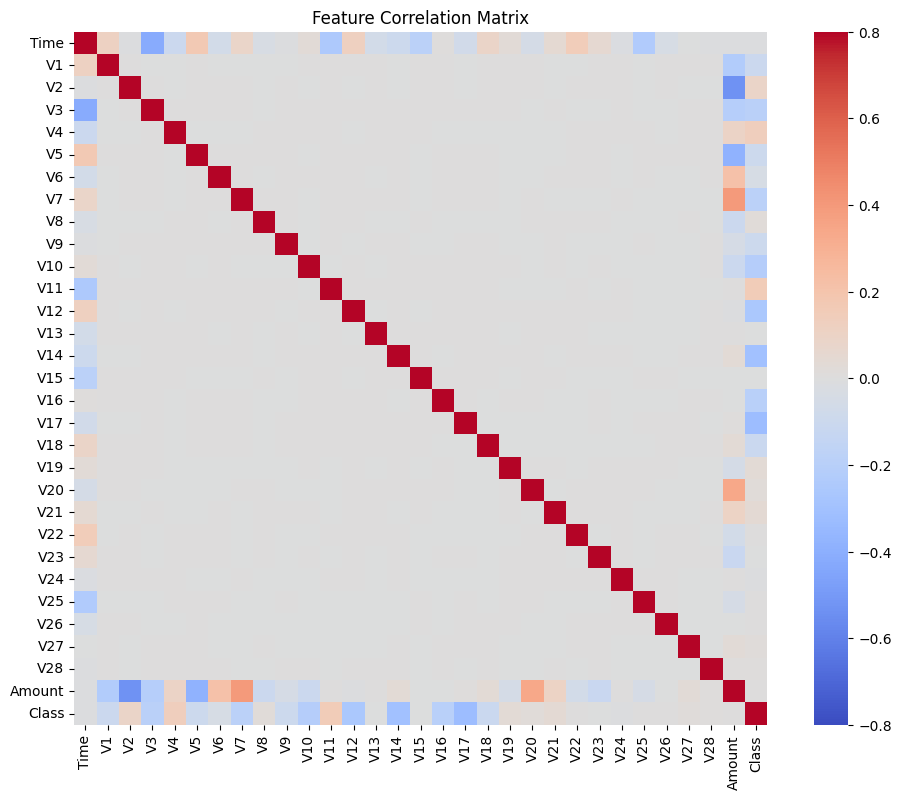

In [11]:
correlation_matrix = df.corr()
fig = plt.figure(figsize = (12, 9))
sns.heatmap(correlation_matrix, cmap = 'coolwarm', vmin = -0.8, vmax = 0.8, square = True)
plt.title('Feature Correlation Matrix')
plt.show()

*Observation*
- The diagonal confirms each feature is perfectly correlated with itself (expected).
- V1-V28 features show very little correlation with each other, confirming they are independent PCA components by design.
- Several features show notable correlation with 'Class':
   - Positive correlation (orange/reddish in Class column): V2, V4, V8, V11 (increase correlation for fraudulent transactions)
   - Negative correlation (blue in Class column): V1, V3, V5, V7, V10, V12, V14, V16, V17, V18 (decrease correlation for fraudulent transactions)
- 'Amount' shows weak correlation with 'Class', reiterate earlier observation that transaction amount alone is insufficient to detect fraud.
- 'Time' shows almost no correlation with 'Class', further supporting our decision to drop it during data preprocessing for model building.
- The features V1-V28 are anonymised PCA components, so no correlation interpretation can be made on these features to real problem.

### Data preprocessing
Based on EDA findings:
- 'Time' is dropped — no distinguishing pattern observed between valid and fraudulent transactions.
- 'Amount' is scaled using StandardScaler as it is the only non-PCA feature retained.
- V1–V28 are already PCA-transformed and do not require preprocessing.


### Scale & Prepare Features

In [12]:
# Drop Time feature
df = df.drop(columns=['Time'])

# Scale Amount
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

# Separate features and target outcome
X = df.drop(columns=['Class'])
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Fraud cases: {y.sum()} ({y.sum() / len(y) * 100:.3f}%)")


Features shape: (284807, 29)
Fraud cases: 492 (0.173%)


### Split dataset into train/test ratio (80/20)
- Use stratify=y to control data split. This ensures the fraud/normal ratio is preserved in both train and test splits since dataset show severe class imbalance.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Fraud in test set: {y_test.sum()}")

Training data shape: (227845, 29)
Test data shape: (56962, 29)
Fraud in test set: 98


### Model building for anomaly detection
- We used simple statistical thresholding-based flagging on 'Amount' and 'Frequency' of transactions, and the results were not able to show distinguishable pattern. In fact, it produced ambiguous results where the valid high-value transaction were flagged as false positive. Statistical methods rely on single feature and not accounting for the correlation between features.

- ML-based anomaly detection allow us to scale up the analysis complexity and use all features simultaneously. By doing this, we will be able to evaluate correlations and patterns that simple statistics fail to capture.

- We will use two ML models to do anomaly detection on the dataset:

1) Isolation Forest (IF) model
- Isolation Forest isolates anomalies by randomly selecting a feature, split on a random value between the feature's min and max, and repeat until an observation is isolated.
- The idea is that anomalies are few and different to normal transaction. So they requere fewer splits to isolate, resulting in shorter path lengths in the decision tree. As anomaly is calculated based on the path lenght, the shorter the path, the more likely the observation is an anomaly.

- We chose IF model because:
   - It uses 1 feature per split, no distance calculations needed, so it work efficiently with high-dimensional data (our dataset have 29 features!) with low computation cost.
   - It is scalable to large dataset such as ours with mare than 280K transactions.
   - It does not assume any undrelying data distribution, which is important given the heavily imbalanced dataset we had.
   
2) Local Outlier Factor (LOF)
- LOF is a density-based method that computes the local density deviation of each data point (transaction) relative to its neighbours. Points (transactions) in a significantly lower density regions than their neighbours are flagged as outliers.
- Interestingly, LOF inspect transactions within its own local cluster, enabling anomaly detection even if the whole data can appear normal. IF is not able to do this effectively.

- We chose LOF as a complementary model to IF because:
   - Its density-based approach is fundamentally different mechanisms to IF random splits mechanism.
   - It detects fraud/anomaly within local cluster, even when global clusetr look normal.

- LOF limitation: relies on distance metrics to define neighbourhoods, which can be less meaningful in high dimensional dataset. This is where IF model is expected to outperform LOF.
- The parameter 'n_neighbors' controls how many neighbours are considered. We use 'n_neighbours = 20', which is recommended as a general default.

*NOTE: We train models without the 'Class' (target outcome) label. We then evaluate models performance against the groudn truth labels to benchmark how well models detect fraudulent transactions.*

   

### Isolation Forest model


In [14]:
# Fit Isolation Forest on training data
# No assumption made about the proportion of anomalies in the dataset - we won't know how many fraudsters in real fresh dataset so set 'contamination = auto'
# NOTE: initial modeling with 'contamination = auto' resulted in many False positives. Knowing the expected fraud rates improves model performance, so we set
# contamination to the known rate in the dataset.

# Contamination rate 
contamination = y.sum() / len(y)
print(f"Contamination: {contamination:.4f}")

iso_forest = IsolationForest(n_estimators=100,
                             # contamination='auto',   # contamination set to 'auto' reflecting unsupervised model, as one wouldn't know the true fraud rate upfront. 
                             random_state=RANDOM_SEED) 

iso_forest.fit(X_train)

# Predict on test data
y_pred_iso = iso_forest.predict(X_test)

# Isolation Forest return binary prediction 1 = normal, -1 = anomaly
# Map to match target output: 0 = valid, 1 = fraud
y_pred_iso = (y_pred_iso == -1).astype(int) 

Contamination: 0.0017


In [15]:
print("Predicted fraud cases:", y_pred_iso.sum())
print("Actual fraud cases:", y_test.sum())
print(f"Correct fraud detections:", ((y_pred_iso == 1) & (y_test.values == 1)).sum())

Predicted fraud cases: 2135
Actual fraud cases: 98
Correct fraud detections: 82


### Isolation Forest evaluation

In [16]:
#Convert y_test to np.array to align with model prediction output
print("Isolation Forest classification report:")
print(classification_report(y_test.values, y_pred_iso, target_names=['Valid', 'Fraud']))

Isolation Forest classification report:
              precision    recall  f1-score   support

       Valid       1.00      0.96      0.98     56864
       Fraud       0.04      0.84      0.07        98

    accuracy                           0.96     56962
   macro avg       0.52      0.90      0.53     56962
weighted avg       1.00      0.96      0.98     56962



ROC_AUC score: 0.95


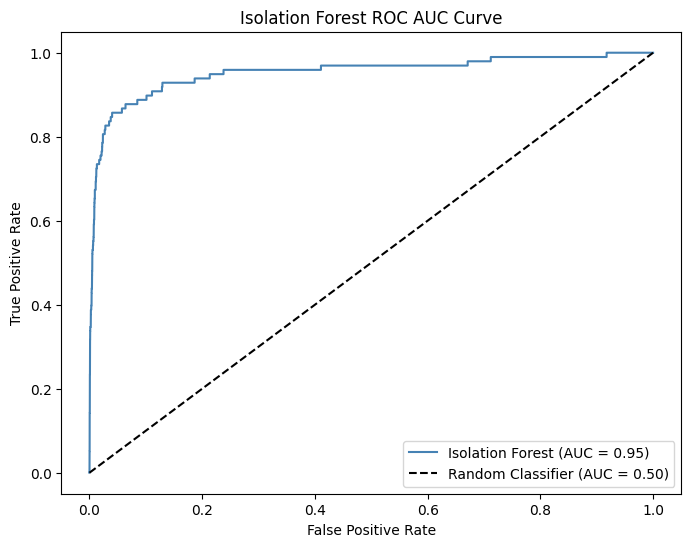

In [17]:
# ROC_AUC Score
iso_score = iso_forest.decision_function(X_test)
ROC_AUC = roc_auc_score(y_test.values, -iso_score)
print(f"ROC_AUC score: {ROC_AUC:.2f}")

# Plot ROC-AUC curve
fpr, tpr, _ = roc_curve(y_test.values, -iso_score)

fig, ax = plt.subplots(figsize = (8, 6))
ax.plot(fpr, tpr, color = 'steelblue',
        label = f'Isolation Forest (AUC = {ROC_AUC:.2f})')
ax.plot([0, 1], [0, 1], 'k--', 
        label='Random Classifier (AUC = 0.50)')
ax.set_title('Isolation Forest ROC AUC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')

plt.show()

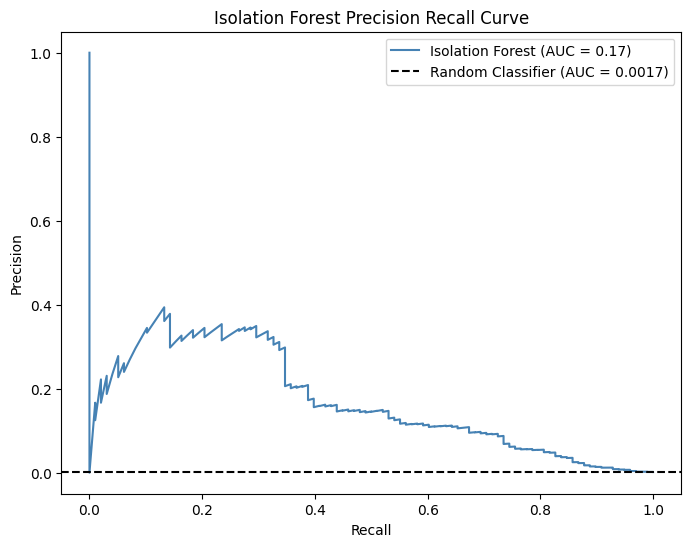

In [18]:
# Precision-Recall Curve
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test.values, -iso_score)
pr_auc = auc(recall, precision)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall, precision, color='steelblue',
        label=f'Isolation Forest (AUC = {pr_auc:.2f})')
ax.axhline(y=y_test.mean(), color='k', linestyle='--',
           label=f'Random Classifier (AUC = {y_test.mean():.4f})')
ax.set_title('Isolation Forest Precision Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(loc='upper right')
plt.show()

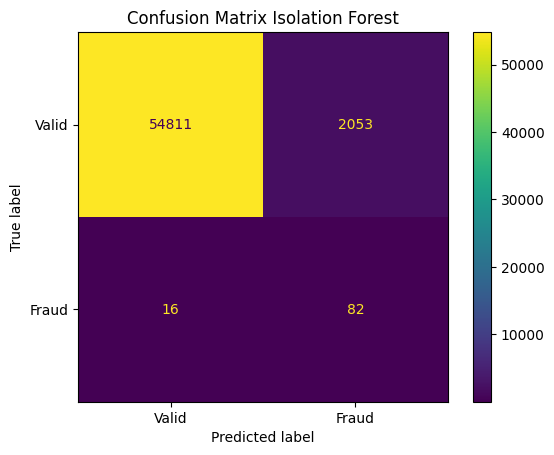

In [19]:
# Confusion matrix
cm_iso = confusion_matrix(y_test.values, y_pred_iso)
ConfusionMatrixDisplay(confusion_matrix=cm_iso,
                       display_labels=['Valid', 'Fraud']).plot(cmap='viridis')
plt.title('Confusion Matrix Isolation Forest')
plt.show()

**Isolation Forest Results**

| Metric | Valid | Fraud |
|--------|-------|-------|
| Precision | 1.00 | 0.04 |
| Recall | 0.96 | 0.84 |
| F1 Score | 0.98 | 0.07 |

- ROC-AUC: 0.95

**Confusion Matrix**
| | Predicted Valid | Predicted Fraud |
|--------|-------|-------|
| **Actual Valid** | 54,811 (TN) | 2,053 (FP) |
| **Actual Fraud** | 16 (FN) | 82 (TP) |

*Observations*
- The model correctly identified **82 out of 98 fraud cases** (recall = 0.84) - strong performance for an unsupervised model with no fraud labels during training.
- **16 fraud cases were missed** (false negatives) — these are the most costly errors in fraud detection.
- **2,053 valid transactions were incorrectly flagged** as fraud (false positives) — resulting in very low precision of 0.04.
- **ROC-AUC of 0.95** indicates excellent overall discrimination ability between valid and fraudulent transactions but is partly affected by the large number of TN (54,811 valid transactions classified correctly).
- **PR-AUC = 0.17** tells a better story. When the model flags fraud, precision drops significantly as recall increases. The model struggles to maintain high precision while catching more fraud cases.
- The low precision reflects the fundamental challenge of anomaly detection on heavily imbalanced data — the model casts a wide net to catch fraud, inevitably flagging many valid transactions along the way.
- The large gap between ROC-AUC and PR-AUC is characteristic of heavily imbalanced datasets — **PR-AUC is the more reliable metric here**.
- Random classifier baseline for PR curve is just 0.0017 (the fraud rate), so PR-AUC of 0.17 is still 100x better than random, but far from perfect.
- This highlights the fundamental challenge of fraud detection, achieving high recall without sacrificing precision is difficult when fraud cases represent only 0.172% of transactions.


### Local Outlier Factor (LOF)

